# NoteBook 3 - Reseau de Neurones (MLP) pour la prediction de pannes

Ce notebook applique un **Perceptron Multi-Couches (MLP)** au gold dataset pour predire `label_failure_next_24h`.
Il reprend le meme preprocessing que NoteBook2 et compare avec RF, LR, XGBoost.

**Contexte** : dataset fortement desequilibre (~5% de pannes), priorite au **recall**.

## 1. Imports

In [6]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score, fbeta_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow : {tf.__version__}")
print(f"GPU dispo  : {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow : 2.21.0
GPU dispo  : False


## 2. Chargement du Gold Dataset

In [7]:
GOLD_PATH = r"C:\Formation\gold_dataset\gold_dataset_20260526-104215.csv"

df = pd.read_csv(GOLD_PATH)
print(f"Shape : {df.shape}")
print(df["label_failure_next_24h"].value_counts())
print(f"Taux de pannes : {df['label_failure_next_24h'].mean()*100:.2f}%")


Shape : (66678, 45)
label_failure_next_24h
False    63468
True      3210
Name: count, dtype: int64
Taux de pannes : 4.81%


## 3. Preprocessing (identique NoteBook2)

In [8]:
# Suppression colonne 100% NaN
if "ambient_humidity_pct" in df.columns:
    df = df.drop(columns=["ambient_humidity_pct"])
    print("'ambient_humidity_pct' supprimee (100% NaN)")

# Severite d'incident manquante = -1 (absence d'incident)
if "incident_max_severity_prev_24h" in df.columns:
    df["incident_max_severity_prev_24h"] = df["incident_max_severity_prev_24h"].fillna(-1)

# Interpolation des series temporelles (temp & pression)
temporal_cols = [c for c in df.columns if "temp_" in c or "pressure_" in c]
df[temporal_cols] = df[temporal_cols].interpolate(method="linear", limit_direction="both")

# NaN restants -> mediane
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"NaN restants : {df.isnull().sum().sum()}")
print(f"Shape final  : {df.shape}")


'ambient_humidity_pct' supprimee (100% NaN)
NaN restants : 0
Shape final  : (66678, 44)


## 4. Split Train / Test

In [9]:
TARGET = "label_failure_next_24h"

# Colonnes a exclure : identifiants, dates, cible, autres labels
META_COLS = [
    "machine_code", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h",
    "label_failure_next_24h", "label_failure_next_48h"
]

# Uniquement float64 et int64
feature_cols = [
    c for c in df.columns
    if c not in META_COLS and df[c].dtype in ["float64", "int64"]
]
print(f"Features : {len(feature_cols)}")
print(feature_cols)

train = df[df["split_set"] == "train"].copy()
test  = df[df["split_set"] == "test"].copy()

X_train, y_train = train[feature_cols], train[TARGET].astype(int)
X_test,  y_test  = test[feature_cols],  test[TARGET].astype(int)

print(f"Train : {X_train.shape} | Positifs : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test  : {X_test.shape}  | Positifs : {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Features : 36
['temp_mean_6h', 'temp_max_6h', 'temp_std_6h', 'pressure_mean_6h', 'pressure_max_6h', 'pressure_std_6h', 'temp_mean_12h', 'temp_max_12h', 'temp_std_12h', 'pressure_mean_12h', 'pressure_max_12h', 'pressure_std_12h', 'temp_mean_24h', 'temp_max_24h', 'temp_std_24h', 'pressure_mean_24h', 'pressure_max_24h', 'pressure_std_24h', 'temp_trend_6h', 'pressure_trend_6h', 'temp_zscore_24h', 'incident_count_prev_24h', 'incident_max_severity_prev_24h', 'incident_count_prev_7d', 'hours_since_last_incident', 'type_surchauffe_count_prev_24h', 'type_baisse_pression_count_prev_24h', 'type_vibration_count_prev_24h', 'type_bruit_mecanique_count_prev_24h', 'type_surconsommation_count_prev_24h', 'type_blocage_mecanique_count_prev_24h', 'type_alarme_capteur_count_prev_24h', 'type_arret_urgence_count_prev_24h', 'type_defaut_qualite_count_prev_24h', 'ambient_temp_c', 'ambient_pressure_hpa']
Train : (46663, 36) | Positifs : 2393 (5.1%)
Test  : (10010, 36)  | Positifs : 336 (3.4%)


## 5. Normalisation & Poids de classe

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"Poids classe 0 : {cw[0]:.3f}")
print(f"Poids classe 1 : {cw[1]:.3f}  (ratio x{cw[1]/cw[0]:.1f})")


Poids classe 0 : 0.527
Poids classe 1 : 9.750  (ratio x18.5)


## 6. Architecture MLP

```
Input (n features)
  Dense(128, ReLU) -> BatchNorm -> Dropout(0.3)
  Dense(64,  ReLU) -> BatchNorm -> Dropout(0.2)
  Dense(32,  ReLU) -> Dropout(0.1)
  Dense(1, Sigmoid)
```

- **BatchNormalization** : stabilise l'entrainement sur donnees heterogenes
- **Dropout** : regularisation contre l'overfitting
- **class_weight** : penalise 20x plus les faux negatifs (pannes manquees)

In [11]:
tf.random.set_seed(42)
np.random.seed(42)

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(1, activation="sigmoid")
    ], name="MLP_PannePrediction")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.Precision(name="precision")
        ]
    )
    return model

model = build_mlp(X_train_sc.shape[1])
model.summary()


Model: "MLP_PannePrediction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,873 (62.00 KB)

 Trainable params: 15,489 (60.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 7. Entrainement

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall", patience=12,
        restore_best_weights=True, mode="max", verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=512,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc: 0.5796 - loss: 0.7120 - precision: 0.0611 - recall: 0.6090 - val_auc: 0.5817 - val_loss: 0.6315 - val_precision: 0.0940 - val_recall: 0.4006 - learning_rate: 0.0010
Epoch 2/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.6503 - loss: 0.6547 - precision: 0.0752 - recall: 0.5846 - val_auc: 0.5386 - val_loss: 0.6715 - val_precision: 0.0775 - val_recall: 0.5263 - learning_rate: 0.0010
Epoch 3/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.6699 - loss: 0.6395 - precision: 0.0810 - recall: 0.6095 - val_auc: 0.5697 - val_loss: 0.7374 - val_precision: 0.0869 - val_recall: 0.7135 - learning_rate: 0.0010
Epoch 4/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.7019 - loss: 0.6167 - precision: 0.0894 - recall: 0.6363 - val_auc: 0.5752 - val_loss: 0.7647 - val_precision: 0.0879 - val_recall: 0.7281 - learning_rate: 0.0010
Epoch 5/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.7165 - loss: 0.6067 - precision: 0.0931 - recal

## 8. Courbes d'apprentissage

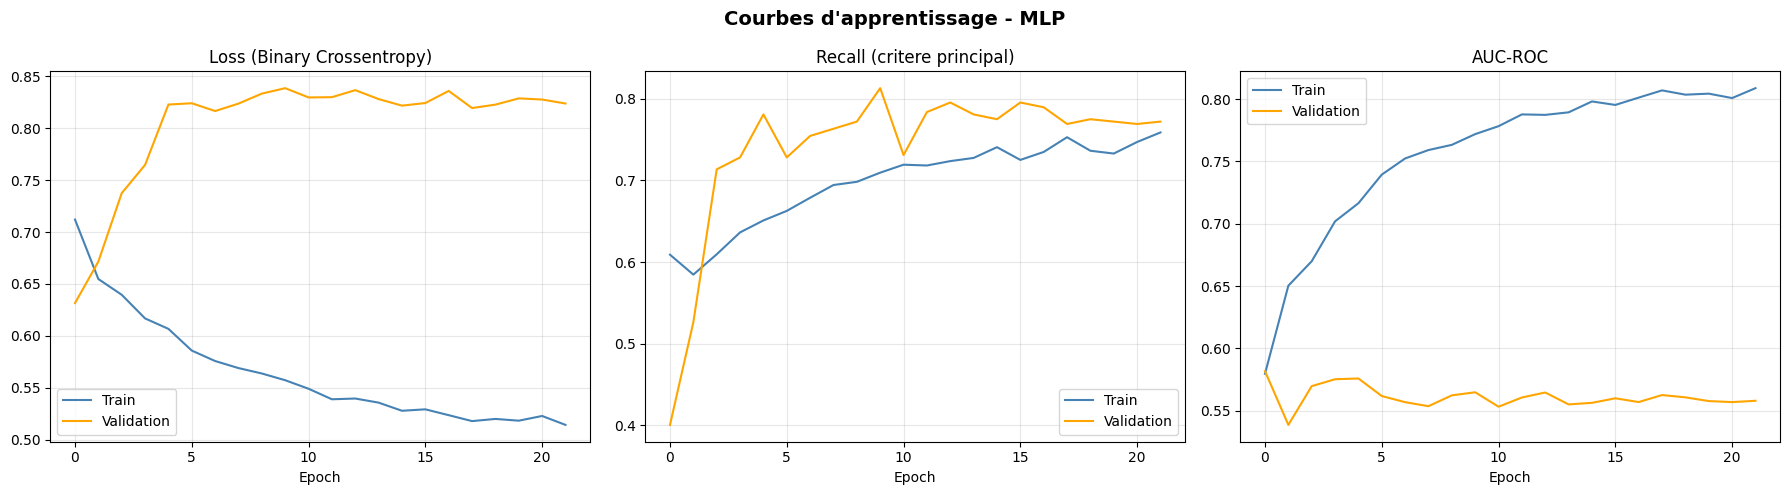

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes d'apprentissage - MLP", fontsize=14, fontweight="bold")

for ax, metric, title in zip(
    axes,
    ["loss", "recall", "auc"],
    ["Loss (Binary Crossentropy)", "Recall (critere principal)", "AUC-ROC"]
):
    ax.plot(history.history[metric], label="Train", color="steelblue")
    ax.plot(history.history[f"val_{metric}"], label="Validation", color="orange")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Optimisation du seuil (score F2)

On cherche le seuil qui maximise le **score F2** (recall pondere 2x vs precision).

Meilleur seuil (F2) : 0.1223
  Recall    : 0.9613
  Precision : 0.0359
  F2        : 0.1563


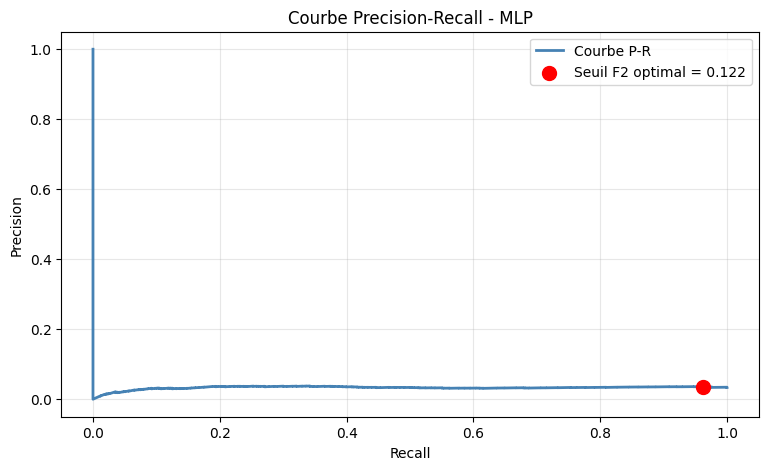

In [14]:
y_proba = model.predict(X_test_sc, verbose=0).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"Meilleur seuil (F2) : {best_threshold:.4f}")
print(f"  Recall    : {recalls[best_idx]:.4f}")
print(f"  Precision : {precisions[best_idx]:.4f}")
print(f"  F2        : {f2_scores[best_idx]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(recalls, precisions, color="steelblue", linewidth=2, label="Courbe P-R")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5, s=100,
            label=f"Seuil F2 optimal = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - MLP")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. Evaluation finale

In [15]:
y_pred = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

recall_val    = recall_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
f1_val        = f1_score(y_test, y_pred)
f2_val        = fbeta_score(y_test, y_pred, beta=2)
auc_val       = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("     RESULTATS MLP (seuil optimise F2)")
print("=" * 50)
print(f"  Seuil : {best_threshold:.4f}")
print(f"  TP : {tp:5d}  |  FN : {fn:5d}")
print(f"  FP : {fp:5d}  |  TN : {tn:5d}")
print("-" * 50)
print(f"  Recall    : {recall_val:.4f}")
print(f"  Precision : {precision_val:.4f}")
print(f"  F1        : {f1_val:.4f}")
print(f"  F2        : {f2_val:.4f}")
print(f"  AUC-ROC   : {auc_val:.4f}")
print("=" * 50)


     RESULTATS MLP (seuil optimise F2)
  Seuil : 0.1223
  TP :   323  |  FN :    13
  FP :  8665  |  TN :  1009
--------------------------------------------------
  Recall    : 0.9613
  Precision : 0.0359
  F1        : 0.0693
  F2        : 0.1563
  AUC-ROC   : 0.5038


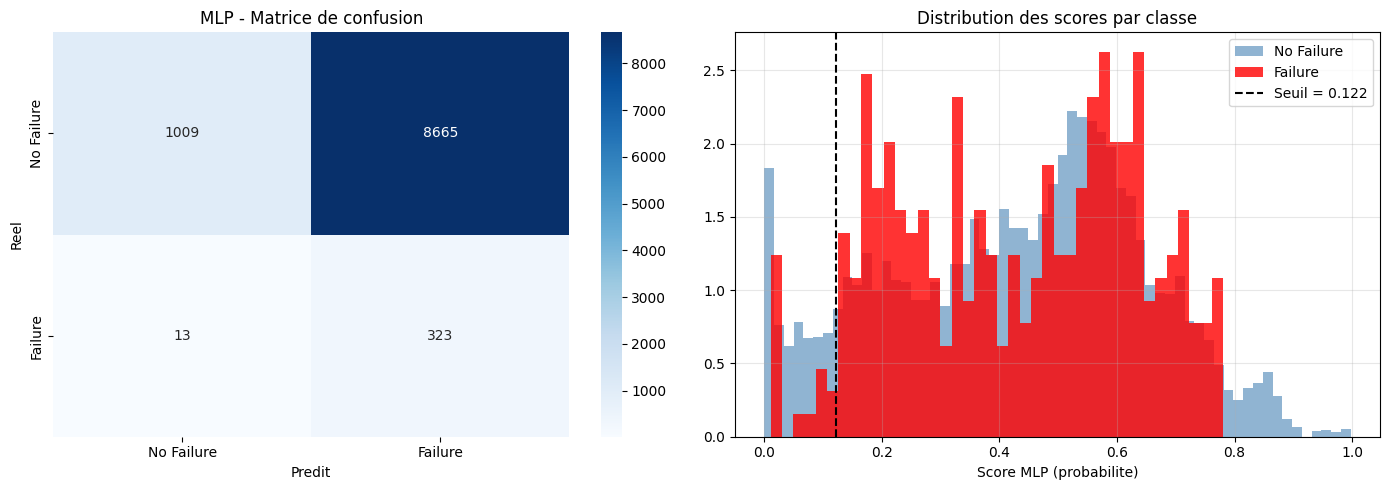

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
axes[0].set_title("MLP - Matrice de confusion")
axes[0].set_ylabel("Reel")
axes[0].set_xlabel("Predit")

axes[1].hist(y_proba[y_test == 0], bins=60, alpha=0.6, color="steelblue", label="No Failure", density=True)
axes[1].hist(y_proba[y_test == 1], bins=40, alpha=0.8, color="red", label="Failure", density=True)
axes[1].axvline(best_threshold, color="black", linestyle="--", label=f"Seuil = {best_threshold:.3f}")
axes[1].set_xlabel("Score MLP (probabilite)")
axes[1].set_title("Distribution des scores par classe")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Comparaison avec les modeles du NoteBook2

In [17]:
nb2_results = [
    {"Modele": "LR tuned",  "TP": 324, "FN": 12,  "FP": 8863, "TN": 811,  "Recall": 0.9643, "Precision": 0.0353, "F1": 0.0680, "AUC-ROC": 0.4941},
    {"Modele": "XGB tuned", "TP": 286, "FN": 50,  "FP": 7656, "TN": 2018, "Recall": 0.8512, "Precision": 0.0360, "F1": 0.0691, "AUC-ROC": 0.5046},
    {"Modele": "LR base",   "TP": 232, "FN": 104, "FP": 6703, "TN": 2971, "Recall": 0.6905, "Precision": 0.0335, "F1": 0.0638, "AUC-ROC": 0.4931},
    {"Modele": "RF tuned",  "TP": 214, "FN": 122, "FP": 5046, "TN": 4628, "Recall": 0.6369, "Precision": 0.0407, "F1": 0.0765, "AUC-ROC": 0.5493},
    {"Modele": "RF base",   "TP": 46,  "FN": 290, "FP": 2074, "TN": 7600, "Recall": 0.1369, "Precision": 0.0217, "F1": 0.0375, "AUC-ROC": 0.4610},
    {"Modele": "XGB base",  "TP": 29,  "FN": 307, "FP": 748,  "TN": 8926, "Recall": 0.0863, "Precision": 0.0373, "F1": 0.0521, "AUC-ROC": 0.5017},
]

mlp_row = {
    "Modele": ">>> MLP (NB3) <<<",
    "TP": int(tp), "FN": int(fn), "FP": int(fp), "TN": int(tn),
    "Recall": round(recall_val, 4), "Precision": round(precision_val, 4),
    "F1": round(f1_val, 4), "AUC-ROC": round(auc_val, 4)
}

df_cmp = pd.DataFrame(nb2_results + [mlp_row])
df_cmp = df_cmp.sort_values("Recall", ascending=False).reset_index(drop=True)
print(df_cmp.to_string(index=False))


           Modele  TP  FN   FP   TN  Recall  Precision     F1  AUC-ROC
         LR tuned 324  12 8863  811  0.9643     0.0353 0.0680   0.4941
>>> MLP (NB3) <<< 323  13 8665 1009  0.9613     0.0359 0.0693   0.5038
        XGB tuned 286  50 7656 2018  0.8512     0.0360 0.0691   0.5046
          LR base 232 104 6703 2971  0.6905     0.0335 0.0638   0.4931
         RF tuned 214 122 5046 4628  0.6369     0.0407 0.0765   0.5493
          RF base  46 290 2074 7600  0.1369     0.0217 0.0375   0.4610
         XGB base  29 307  748 8926  0.0863     0.0373 0.0521   0.5017


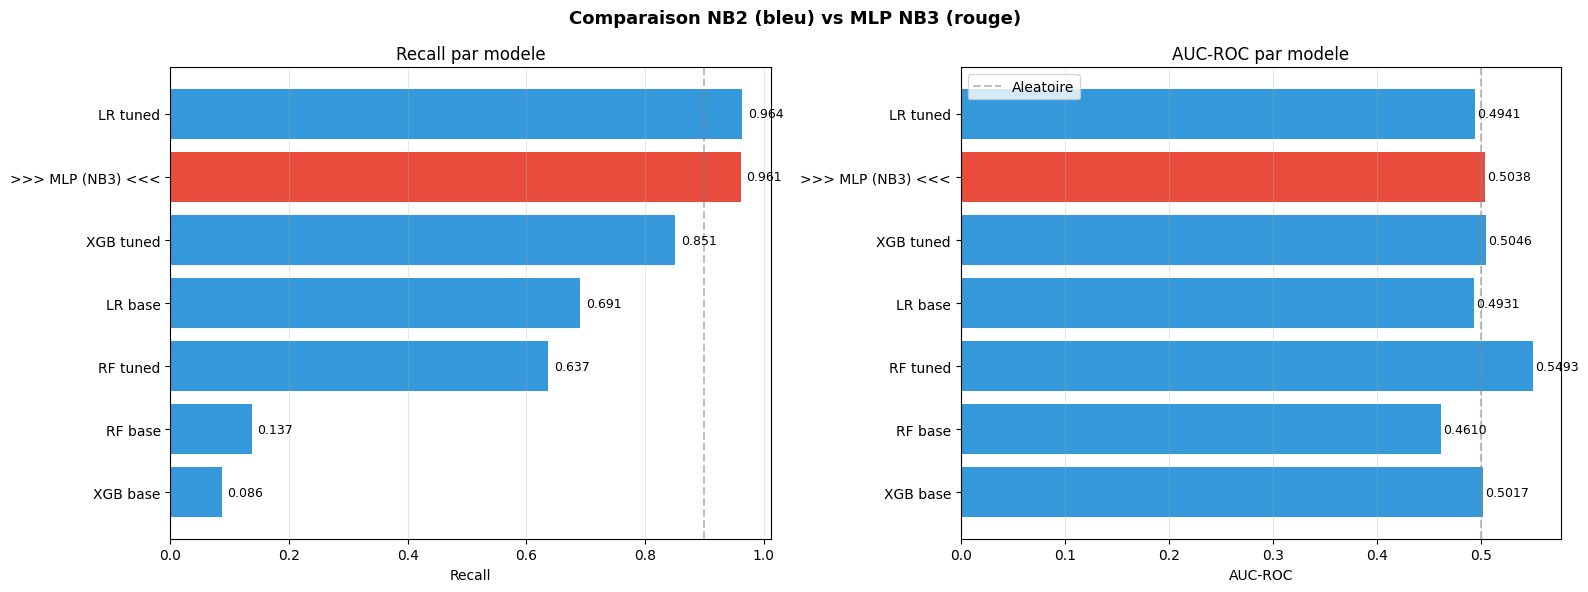

In [18]:
df_plot = pd.DataFrame(nb2_results + [mlp_row])
df_plot = df_plot.sort_values("Recall", ascending=True)
colors = ["#e74c3c" if "MLP" in m else "#3498db" for m in df_plot["Modele"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(df_plot["Modele"], df_plot["Recall"], color=colors)
for bar, val in zip(bars, df_plot["Recall"]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=9)
axes[0].set_xlabel("Recall")
axes[0].set_title("Recall par modele")
axes[0].axvline(0.9, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(axis="x", alpha=0.3)

bars2 = axes[1].barh(df_plot["Modele"], df_plot["AUC-ROC"], color=colors)
for bar, val in zip(bars2, df_plot["AUC-ROC"]):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)
axes[1].set_xlabel("AUC-ROC")
axes[1].set_title("AUC-ROC par modele")
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Aleatoire")
axes[1].legend()
axes[1].grid(axis="x", alpha=0.3)

fig.suptitle("Comparaison NB2 (bleu) vs MLP NB3 (rouge)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Pannes manquees (Faux Negatifs)

Pannes dans le test set : 336
  Detectees (TP)        : 323 (96.1%)
  Manquees  (FN)        : 13 (3.9%)
Score moyen TP : 0.4461
Score moyen FN : 0.0405


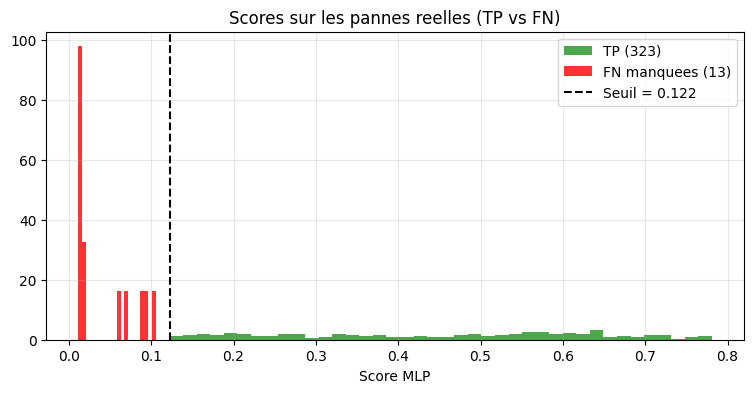

In [19]:
test_copy = test.copy()
test_copy["proba_mlp"] = y_proba
test_copy["pred_mlp"]  = y_pred
test_copy["y_true"]    = y_test.values

fn_df = test_copy[(test_copy["y_true"] == 1) & (test_copy["pred_mlp"] == 0)]
tp_df = test_copy[(test_copy["y_true"] == 1) & (test_copy["pred_mlp"] == 1)]

print(f"Pannes dans le test set : {y_test.sum()}")
print(f"  Detectees (TP)        : {len(tp_df)} ({len(tp_df)/y_test.sum()*100:.1f}%)")
print(f"  Manquees  (FN)        : {len(fn_df)} ({len(fn_df)/y_test.sum()*100:.1f}%)")
print(f"Score moyen TP : {tp_df['proba_mlp'].mean():.4f}")
print(f"Score moyen FN : {fn_df['proba_mlp'].mean():.4f}")

plt.figure(figsize=(9, 4))
plt.hist(tp_df["proba_mlp"], bins=40, alpha=0.7, color="green", label=f"TP ({len(tp_df)})", density=True)
plt.hist(fn_df["proba_mlp"], bins=20, alpha=0.8, color="red", label=f"FN manquees ({len(fn_df)})", density=True)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Seuil = {best_threshold:.3f}")
plt.xlabel("Score MLP")
plt.title("Scores sur les pannes reelles (TP vs FN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Synthese

| | LR tuned (NB2) | MLP (NB3) |
|---|---|---|
| **Recall** | 0.9643 | *voir ci-dessus* |
| **AUC-ROC** | 0.4941 | *voir ci-dessus* |
| **Interpretabilite** | Haute (coefficients) | Faible (boite noire) |
| **Non-linearite** | Non | Oui |

**Atouts du MLP** : capture les interactions non-lineaires entre features, potentiel superieur avec features temporelles sequentielles.

**Recommandation** : si recall MLP >= 96.4% avec AUC-ROC superieur -> privilegier le MLP. Sinon, LR tuned reste le meilleur compromis.